# 一元导数与局部变化

目标：从固定三条合成数据出发，核对解析导数、精确差商与浮点差分。不是通过有限采样证明可导性。依次运行全部单元；遇到预期错误会明确捕获，非预期错误会停止。

## 设置与数据
核心函数来自同目录脚本。保留 data 文件夹。先记录实际环境。

In [1]:
from pathlib import Path
from fractions import Fraction
import math, sys, io
from IPython.display import display, Image
import matplotlib
import matplotlib.pyplot as plt
import experiment as e
base = Path(e.__file__).resolve().parent
print('Python:', sys.version.split()[0])
print('Matplotlib:', matplotlib.__version__)
print('数据存在:', (base/'data/calibration.csv').is_file())
def show_figure(fig):
    buffer = io.BytesIO()
    fig.tight_layout()
    fig.savefig(buffer, format='png', dpi=130, bbox_inches='tight')
    display(Image(data=buffer.getvalue()))
    plt.close(fig)

Python: 3.12.14
Matplotlib: 3.10.8
数据存在: True


In [2]:
data = e.load_data(base/'data/calibration.csv')
print('固定的 (x, y):', data)
print('记录数:', len(data))

固定的 (x, y): ((1.0, 2.0), (2.0, 3.0), (3.0, 5.0))
记录数: 3


## 先完成纸笔核对
固定 w=3/2，预测为 (3/2,3,9/2)，残差为 (-1/2,0,-1/2)。每项导数贡献为 2xᵢrᵢ/3。先预测输出，再运行。

In [3]:
w = 1.5
for x, y in data:
    residual = w*x-y
    print({'x':x, 'y':y, 'prediction':w*x, 'residual':residual, 'derivative_contribution':2*x*residual/len(data)})
print('L(1.5):', e.mean_square_loss(w,data))
print("L'(1.5):", e.loss_derivative(w,data))

{'x': 1.0, 'y': 2.0, 'prediction': 1.5, 'residual': -0.5, 'derivative_contribution': -0.3333333333333333}
{'x': 2.0, 'y': 3.0, 'prediction': 3.0, 'residual': 0.0, 'derivative_contribution': 0.0}
{'x': 3.0, 'y': 5.0, 'prediction': 4.5, 'residual': -0.5, 'derivative_contribution': -1.0}
L(1.5): 0.16666666666666666
L'(1.5): -1.3333333333333333


In [4]:
exact = e.exact_checks()
print(exact)

{'exact_checks_passed': 205, 'loss_at_3_over_2': '1/6', 'derivative_at_3_over_2': '-4/3', 'optimum': '23/14', 'minimum': '1/14', 'loss_at_151_over_100': '769/5000', 'cubic_forward_error_at_h_1_over_20': '61/400', 'cubic_central_error_at_h_1_over_20': '1/400'}


## 切线是局部预测
真实有限变化含有额外的二次项。h=1/2 已经太大，不能只凭负斜率预言下降。

In [5]:
for h in [.01, .1, .5]:
    actual = e.mean_square_loss(w+h,data)-e.mean_square_loss(w,data)
    linear = e.loss_derivative(w,data)*h
    print({'h':h,'linear_change':linear,'actual_change':actual,'remainder':actual-linear})

{'h': 0.01, 'linear_change': -0.013333333333333332, 'actual_change': -0.012866666666666748, 'remainder': 0.00046666666666658405}
{'h': 0.1, 'linear_change': -0.13333333333333333, 'actual_change': -0.08666666666666675, 'remainder': 0.04666666666666658}
{'h': 0.5, 'linear_change': -0.6666666666666666, 'actual_change': 0.5, 'remainder': 1.1666666666666665}


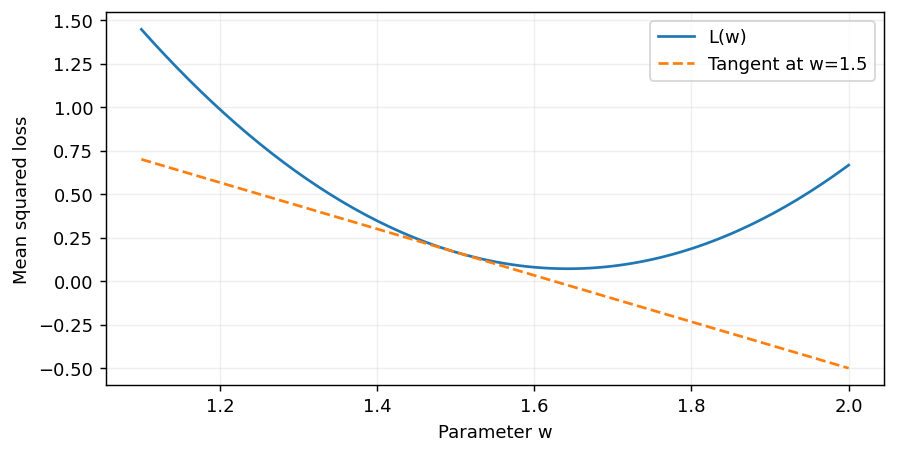

In [6]:
grid = [1.1+i/200 for i in range(181)]
fig, ax = plt.subplots(figsize=(7,3.6))
ax.plot(grid,[e.mean_square_loss(z,data) for z in grid],label='L(w)')
ax.plot(grid,[e.mean_square_loss(w,data)+e.loss_derivative(w,data)*(z-w) for z in grid],ls='--',label='Tangent at w=1.5')
ax.set(xlabel='Parameter w',ylabel='Mean squared loss')
ax.grid(alpha=.2);ax.legend();show_figure(fig)

## 精确差商与浮点扫描
对于 x³ 在 x=1，前向误差 3h+h²，中心误差 h²。先用 Fraction 保留精确的 h=1/20。

In [7]:
h = Fraction(1,20)
forward = ((1+h)**3-1)/h
central = ((1+h)**3-(1-h)**3)/(2*h)
print('前向估计和误差:', forward, forward-3)
print('中心估计和误差:', central, central-3)

前向估计和误差: 1261/400 61/400
中心估计和误差: 1201/400 1/400


In [8]:
steps = [10.**(-k) for k in range(1,18)]
cubic_scan = e.scan_steps(lambda z:z**3,1,3,steps)
for row in cubic_scan:
    print(row['method'],f"h={row['h']:.0e}", row['status'], row.get('absolute_error'),row.get('reason',''))

forward h=1e-01 ok 0.31000000000000405 
central h=1e-01 ok 0.010000000000001563 
forward h=1e-02 ok 0.03010000000001334 
central h=1e-02 ok 0.0001000000000055401 
forward h=1e-03 ok 0.0030009999997275827 
central h=1e-03 ok 9.999998633603013e-07 
forward h=1e-04 ok 0.00030000999873536216 
central h=1e-04 ok 9.999448380426657e-09 
forward h=1e-05 ok 3.0000110953221082e-05 
central h=1e-05 ok 9.736877970567548e-11 
forward h=1e-06 ok 2.999797857228259e-06 
central h=1e-06 ok 8.026646014513972e-11 
forward h=1e-07 ok 3.0151181817927863e-07 
central h=1e-07 ok 8.626699354863376e-11 
forward h=1e-08 ok 3.972047579736682e-09 
central h=1e-08 ok 7.130182666514884e-09 
forward h=1e-09 ok 2.482211129972711e-07 
central h=1e-09 ok 8.168765930349764e-08 
forward h=1e-10 ok 2.482211129972711e-07 
central h=1e-10 ok 2.482211129972711e-07 
forward h=1e-11 ok 2.482211129972711e-07 
central h=1e-11 ok 2.482211129972711e-07 
forward h=1e-12 ok 0.00026670174702303484 
central h=1e-12 ok 0.00010016829332

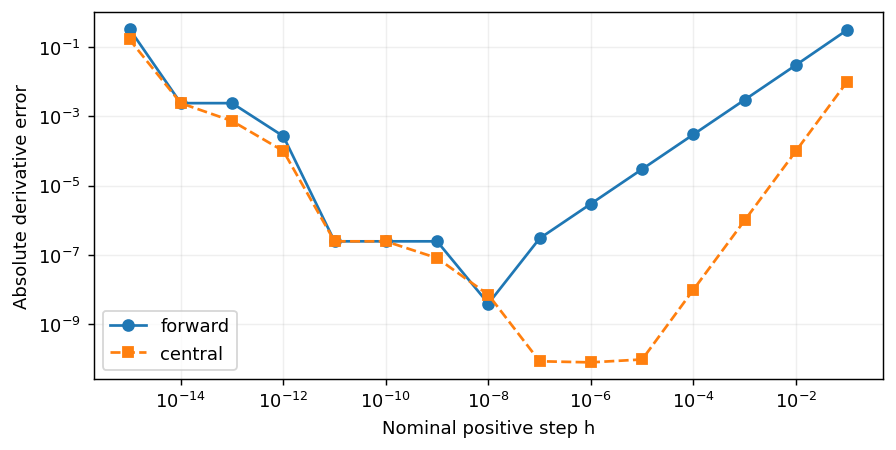

零误差未进入对数线: 0
被拒绝的尝试: 4


In [9]:
fig, ax = plt.subplots(figsize=(7,3.6))
for method, marker, style in [('forward','o','-'),('central','s','--')]:
    positive = [r for r in cubic_scan if r['status']=='ok' and r['absolute_error']>0 and r['method']==method]
    ax.loglog([r['h'] for r in positive],[r['absolute_error'] for r in positive],marker=marker,ls=style,label=method)
ax.set(xlabel='Nominal positive step h',ylabel='Absolute derivative error')
ax.grid(alpha=.2);ax.legend();show_figure(fig)
print('零误差未进入对数线:',sum(r['status']=='ok' and r['absolute_error']==0 for r in cubic_scan))
print('被拒绝的尝试:',sum(r['status']!='ok' for r in cubic_scan))

形状由截断、舍入和输入位移共同决定。零误差没有被伪造成一个正数。接下来核对主损失；它是二次函数，精确算术下中心差分已精确，浮点扫描仍会受舍入影响。

In [10]:
loss_scan = e.scan_steps(lambda z:e.mean_square_loss(z,data),1.5,-4/3,steps)
for row in loss_scan:
    if row['method']=='central':
        print(row['h'],row['status'],row.get('estimate'),row.get('actual_positive_step'),row.get('actual_negative_step'))

0.1 ok -1.333333333333336 0.10000000000000009 0.10000000000000009
0.01 ok -1.333333333333342 0.010000000000000009 0.010000000000000009
0.001 ok -1.3333333333333253 0.0009999999999998899 0.0009999999999998899
0.0001 ok -1.3333333333340192 9.999999999998899e-05 9.999999999998899e-05
1e-05 ok -1.333333333355946 1.0000000000065512e-05 1.0000000000065512e-05
1e-06 ok -1.3333333331588815 9.999999999177334e-07 9.999999999177334e-07
1e-07 ok -1.333333333325415 1.0000000005838672e-07 1.0000000005838672e-07
1e-08 ok -1.3333333256926316 9.99999993922529e-09 9.99999993922529e-09
1e-09 ok -1.333333443653828 1.000000082740371e-09 1.000000082740371e-09
1e-10 ok -1.333333443653828 1.000000082740371e-10 1.000000082740371e-10
1e-11 ok -1.333333443653828 1.000000082740371e-11 1.000000082740371e-11
1e-12 ok -1.333447241513852 1.000088900582341e-12 1.000088900582341e-12
1e-13 ok -1.3337941862090474 9.992007221626409e-14 9.992007221626409e-14
1e-14 ok -1.339206523454095 9.992007221626409e-15 9.9920072216264

## 稳定的中心值不是可导性证据
绝对值与折线在0处没有两侧导数。比较三个公式，不要把某一列输出改名为已经存在的导数。

In [11]:
for name,function in [('abs',abs),('relu',lambda z:max(0,z))]:
    print(name,{method:e.finite_difference(function,0,.1,method)['estimate'] for method in ['backward','forward','central']})

abs {'backward': -1.0, 'forward': 1.0, 'central': 0.0}
relu {'backward': 0.0, 'forward': 1.0, 'central': 0.5}


## 定义域与分辨率失败
每个案例单独保留错误原因。拒绝越界和未移动采样，不能悄悄返回0。

In [12]:
cases = [('log outside domain',lambda:e.finite_difference(math.log,.05,.1)),
         ('unresolved large scale',lambda:e.finite_difference(lambda z:z,1e20,.5)),
         ('unresolved tiny step',lambda:e.finite_difference(lambda z:z,1,1e-20)),
         ('boolean step',lambda:e.finite_difference(lambda z:z*z,1,True))]
for name,call in cases:
    try:
        call()
    except ValueError as error:
        print(name,':',str(error))
    else:
        raise AssertionError('预期失败没有发生: '+name)

log outside domain : math domain error
unresolved large scale : 正向步长在当前尺度下不可分辨
unresolved tiny step : 正向步长在当前尺度下不可分辨
boolean step : h 必须是实数标量，不能用布尔值或字符串代替


In [13]:
print('1附近向上的间隔:',math.ulp(1.0))
print('1e20附近向上的间隔:',math.ulp(1e20))
print('1.0+1e-20仍等于1.0:',1.0+1e-20==1.0)
print('合法对数中心差分:',e.finite_difference(math.log,.05,.01)['estimate'])

1附近向上的间隔: 2.220446049250313e-16
1e20附近向上的间隔: 16384.0
1.0+1e-20仍等于1.0: True
合法对数中心差分: 20.273255405408207


## 独立核验与完整输出
测试明确抛出异常，在优化模式下仍有效。完整结果保留68条扫描尝试，包括拒绝状态。

In [14]:
checks = e.boundary_checks()
print('边界及基本结果检查:',checks['checks_passed'])
report = e.run(output=base/'notebook_results')
print('精确检查:',report['exact']['exact_checks_passed'])
print('扫描尝试:',sum(len(r) for r in report['scans'].values()))
print('输出文件存在:',(base/'notebook_results/report.json').is_file())

边界及基本结果检查: 35
精确检查: 205
扫描尝试: 68
输出文件存在: True


## 结论与下一步
本例手算、解析式、Fraction和有限步长扫描各自提供不同证据。导数为局部变化率；定义域、不可导点、固定状态和浮点尺度都影响核验。写下一个成功核对和一个不能据此推论的结论，再完成独立详解中的练习。

本Notebook已通过新Python进程中的真实进程内内核顺序执行。浏览器UI、外进程socket和本机Anaconda安装未测试。